### 순서

#### 1. 데이터 불러오기
#### 2. 형태소 분석기를 이용하여 품사가 명사인 경우, 해당 단어를 추출하기
#### 3. 추출된 결과로 embedding model 만들기
#### 4. target, attribute 단어 셋 만들기
        - 영화 구분 단어셋
        - 장르 구분 단어셋
#### 5. Embedding model과 단어셋으로 WEAT score 구해보기
#### 6. WEAT score 시각화 
#### 7. 회고

#### 1. 데이터 불러오기

In [ ]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r') as file:
    for i in range(20):
        print(file.readline(), end='')

#### 2. 형태소 분석기를 이용하여 품사가 명사인 경우, 해당 단어를 추출하기

In [2]:
from konlpy.tag import Okt

okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:      # "Adjective", "Verb" 등을 포함할 수도 있습니다.
                res.append(w[0])    # 명사일 때만 tokenized 에 저장하게 됩니다.
        tokenized.append(res)

print("슝~")

슝~


In [3]:
print(len(tokenized))

71156


#### 3. 추출된 결과로 embedding model 만들기

In [4]:
from gensim.models import Word2Vec

# tokenized에 담긴 데이터를 가지고 나만의 Word2Vec을 생성합니다. (Gensim 4.0 기준)
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
model.wv.most_similar(positive=['영화'])

# vector size = 학습 후 임베딩 벡터의 차원
# window = 컨텍스트 윈도우 크기
# min_count = 단어 최소 빈도수 제한 (빈도가 적은 단어들은 학습하지 않아요.)
# workers = 학습을 위한 프로세스 수
# sg = 0은 CBoW, 1은 Skip-gram.

[('작품', 0.8731721043586731),
 ('다큐멘터리', 0.8289102911949158),
 ('드라마', 0.8250898122787476),
 ('형식', 0.7883015871047974),
 ('영화로', 0.7881268858909607),
 ('주제', 0.7803376913070679),
 ('감동', 0.7739487290382385),
 ('코미디', 0.7712402939796448),
 ('소재', 0.7607381343841553),
 ('버자이너', 0.760311484336853)]

##### 훈련 확인

In [5]:
model.wv.most_similar(positive=['사랑'])

[('애정', 0.7041432857513428),
 ('가슴', 0.6966580748558044),
 ('첫사랑', 0.6955289840698242),
 ('만남', 0.6938638687133789),
 ('행복', 0.6926489472389221),
 ('우정', 0.6914366483688354),
 ('진심', 0.6907718181610107),
 ('연애', 0.6863135099411011),
 ('이별', 0.6861243844032288),
 ('연애관', 0.6769065856933594)]

In [50]:
model.wv.most_similar(positive=['연극'])

[('영화감독', 0.9051358103752136),
 ('시나리오', 0.8879470825195312),
 ('배우', 0.8838565349578857),
 ('데뷔', 0.8774248361587524),
 ('아티스트', 0.8716488480567932),
 ('연기', 0.8672608733177185),
 ('오페라', 0.866125762462616),
 ('영감', 0.8654337525367737),
 ('공연', 0.8632829189300537),
 ('예술가', 0.8626229763031006)]

#### 4. target, attribute 단어 셋 만들기
#### TF/IDF로 해당 데이터를 가장 잘 표현하는 단어 셋 만들기

In [7]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)

슝~


In [9]:
art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


#### 영화 구분 단어셋

In [10]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)

(2, 41082)


In [11]:
print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

23976
영화


In [12]:
m1 = X[0].tocoo()   # art를 TF-IDF로 표현한 sparse matrix를 가져옵니다.
m2 = X[1].tocoo()   # gen을 TF-IDF로 표현한 sparse matrix를 가져옵니다.

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)   #art를 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.
w2.sort(key=lambda x: x[1], reverse=True)   #gen을 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

print('\n')

print('일반영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 시간, 다시, 아들, 소녀, 아내, 다른, 영화제, 사이, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 아빠, 생활, 통해, 모습, 기억, 죽음, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 결혼, 사고, 전쟁, 위기, 때문, 이제, 최고, 이자, 과거, 일상, 경찰, 간다, 상황, 미국, 운명, 결심, 관계, 현실, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 만난, 감정, 처음, 국제, 누구, 살인, 충격, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 의도, 동생, 하루, 위기, 계획, 정체, 한국, 

양쪽에 중복된 단어가 많음 -> 두 개념축이 대조되도록 하기 위해서는 서로 중복되지 않게 단어셋을 추출해야함

#### 중복단어 제외하고 상위 15개 단어 추출

In [13]:
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

# w1에만 있고 w2에는 없는, 예술영화를 잘 대표하는 단어를 15개 추출한다.
target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_art.append(w1_[i])
    if len(target_art) == n: break

# w2에만 있고 w1에는 없는, 일반영화를 잘 대표하는 단어를 15개 추출한다.
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_gen.append(w2_[i])
    if len(target_gen) == n: break

In [14]:
print(target_art)

['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']


In [15]:
print(target_gen)

['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


#### 장르 구분 단어셋

In [53]:
genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt',
    'synopsis_horror.txt', 'synopsis_etc.txt', 'synopsis_documentary.txt',
    'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
    'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt',
    'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt',
    'synopsis_animation.txt', 'synopsis_action.txt', 'synopsis_adventure.txt',
    'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']

genre_name = [
    '드라마', '멜로로맨스', '액션', '코미디', '전쟁', '공포(호러)',
    'SF', '가족', '공연', '기타', '다큐멘터리', '뮤지컬',
    '미스터리', '범죄', '사극', '서부극(웨스턴)', '성인물(에로)',
    '스릴러', '애니메이션', '어드벤처', '판타지']

In [54]:
# 약 10분정도 걸립니다.
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.


In [55]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

(21, 42191)


In [56]:
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while (len(attr) < 15):
        if vectorizer.get_feature_names_out()[w[i][j][0]] in model.wv:
            attr.append(vectorizer.get_feature_names_out()[w[i][j][0]])
            print(vectorizer.get_feature_names_out()[w[i][j][0]], end=', ')
        j += 1
    attributes.append(attr)
    print()

드라마: 위해, 자신, 지구, 시작, 사람, 인류, 인간, 미래, 우주, 그녀, 로봇, 세계, 모든, 박사, 우주선, 
멜로로맨스: 엄마, 아빠, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 아들, 국제, 마을, 낙타, 
액션: 오페라, 사랑, 토스카, 실황, 올레, 자신, 카바, 그녀, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 위해, 
코미디: 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
전쟁: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 뉴미디어, 페스티벌, 
공포(호러): 영화제, 영화, 다큐, 국제, 다큐멘터리, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 
SF: 자신, 영화제, 그녀, 사람, 사랑, 영화, 위해, 시작, 국제, 남자, 친구, 이야기, 엄마, 여자, 아버지, 
가족: 그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 아내, 
공연: 뮤지컬, 사랑, 에스메랄다, 그녀, 음악, 충무로, 모차르트, 영화, 토스카, 자신, 니웨, 카바, 영화제, 바흐, 프롤, 
기타: 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 아이, 
다큐멘터리: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살해, 
뮤지컬: 조선, 위해, 시작, 신기전, 사랑, 자신, 아가멤논, 황제, 그녀, 루안, 사람, 운명, 최고, 하선, 전쟁, 
미스터리: 서부, 보안관, 위해, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 자신, 개릿, 아이, 시작, 무법자, 프린트, 태구, 
범죄: 그녀, 남편, 마사지, 자신, 섹스, 관계, 영화, 정사, 남자, 위해, 시작, 여자, 유부녀, 마음, 사랑, 
사극: 자신, 그녀, 사건, 시작, 위해, 사람, 

#### 5. Embedding model과 단어셋으로 WEAT score 구해보기

In [23]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

In [57]:
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B #, c_a, c_b

def weat_score(X, Y, A, B):

    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

In [58]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

In [59]:
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

In [ ]:
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        print(genre_name[i], genre_name[j],matrix[i][j])

#### 해석 방법

- 해석은 예술영화 − 일반영화 의미 축을 기준으로 함

- 멜로로맨스와 드라마 간의 상대적 차이를 의미

- 해석: A가 B에 비해 X에 가깝다.

    - 단, 특정 수치를 기준으로 판단할 수 없음. 즉, A는 X에 가깝고 B는 Y에 가깝다는 해석 불가능
      1. 양수일 때 : A 장르가 예술영화(X)와 가깝다
      2. 음수일 때 : A 장르가 일반영화(Y)와 가깝다

#### 6. WEAT score 시각화 

In [ ]:
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum

In [62]:
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

<Axes: >

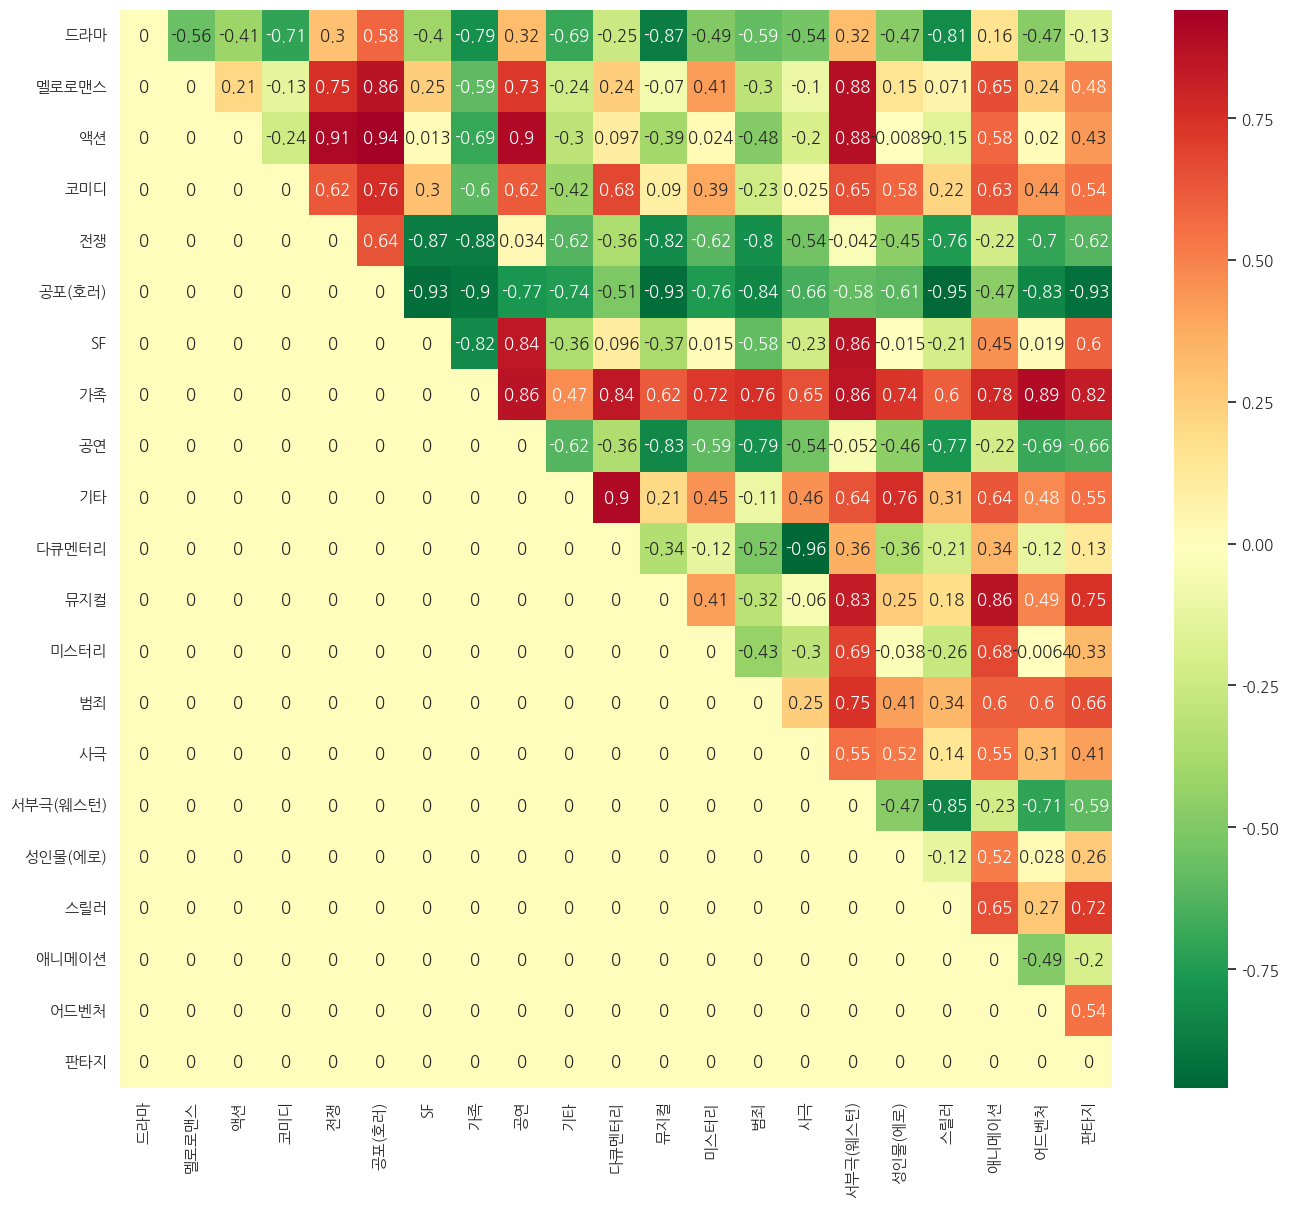

In [64]:
import numpy as np;
import seaborn as sns;

np.random.seed(0)

# 한글 지원 폰트
sns.set(font='NanumGothic')

# 마이너스 부호
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(16, 14))

ax = sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name, annot=True,  cmap='RdYlGn_r')
ax

#### 편향성이 가장 높은 Top 20 list 

In [78]:
results = []
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        results.append([genre_name[i], genre_name[j], matrix[i][j]])

results.sort(key=lambda x: abs(x[2]), reverse=True)
high_20_list = results[:20]

high_20_list

[['다큐멘터리', '사극', -0.95887107],
 ['공포(호러)', '스릴러', -0.94819343],
 ['액션', '공포(호러)', 0.9414657],
 ['공포(호러)', 'SF', -0.9341895],
 ['공포(호러)', '뮤지컬', -0.9339861],
 ['공포(호러)', '판타지', -0.92560834],
 ['액션', '전쟁', 0.9116003],
 ['기타', '다큐멘터리', 0.9035296],
 ['액션', '공연', 0.90071076],
 ['공포(호러)', '가족', -0.89991117],
 ['가족', '어드벤처', 0.8903931],
 ['액션', '서부극(웨스턴)', 0.8799301],
 ['멜로로맨스', '서부극(웨스턴)', 0.8753147],
 ['전쟁', '가족', -0.87525666],
 ['전쟁', 'SF', -0.8725277],
 ['드라마', '뮤지컬', -0.87243915],
 ['뮤지컬', '애니메이션', 0.8647359],
 ['SF', '서부극(웨스턴)', 0.86143285],
 ['가족', '공연', 0.86110246],
 ['멜로로맨스', '공포(호러)', 0.85989577]]

#### 편향성이 가장 낮은 Top 20 list 

In [79]:
results = []
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        results.append([genre_name[i], genre_name[j], matrix[i][j]])

results.sort(key=lambda x: abs(x[2]))
low_20_list = results[:20]

low_20_list

[['미스터리', '어드벤처', -0.006420017],
 ['액션', '성인물(에로)', -0.008919543],
 ['액션', 'SF', 0.013046992],
 ['SF', '미스터리', 0.014520591],
 ['SF', '성인물(에로)', -0.015216332],
 ['SF', '어드벤처', 0.018537017],
 ['액션', '어드벤처', 0.020181684],
 ['액션', '미스터리', 0.023964906],
 ['코미디', '사극', 0.025103197],
 ['성인물(에로)', '어드벤처', 0.02779879],
 ['전쟁', '공연', 0.034212258],
 ['미스터리', '성인물(에로)', -0.03823322],
 ['전쟁', '서부극(웨스턴)', -0.04169213],
 ['공연', '서부극(웨스턴)', -0.051963843],
 ['뮤지컬', '사극', -0.059710804],
 ['멜로로맨스', '뮤지컬', -0.069530256],
 ['멜로로맨스', '스릴러', 0.07114535],
 ['코미디', '뮤지컬', 0.09019545],
 ['SF', '다큐멘터리', 0.095887676],
 ['액션', '다큐멘터리', 0.09655398]]

### 회고

편향성이 0에 가깝다는 것은 임베딩 모델이 판단하기에 어느 것이 가깝다고 결론 내리기 어렵다는 것

그렇다면

1. 내가 영화구분과 장르구분하는 단어셋의 대표 단어들을 잘 못만들었을까?(중복을 제거 잘 못해서..) 

2. 아니면, 장르를 구분하는 단어셋을 잘 만들었기 때문에 편향성이 거의 없는 것일까?

지금은 영화 관련 장르이기 때문에 이 판단을 하기에는 어려운 것 같다. 예를들어 전쟁 영화도 예술영화일수도 있고 일반(상업)영화일 수도 있으니까(해석하기 나름인듯)

만약에 조금 더 명확한 판단을 할 수 있는 데이터셋이라면 해석하기는 조금 쉬울 수도 있겠다.